# 🐕 Late Fusion Finale — Détection de chiens errants à risque de rage

Combine **comportement** (3 modèles, 16 classes) et **voix** (2 modèles, 5 classes) en une décision **NORMAL / ANORMAL**.

Inclut la **gestion du silence** : si la vidéo n'a pas de vocalisation, le système bascule automatiquement en mode comportement seul.

In [1]:
import os
for root, dirs, files in os.walk('/kaggle/input/'):
    for f in files:
        print(os.path.join(root, f))

/kaggle/input/datasets/zeinebbayoudh7/late-fusion-data/behav_true_labels.npy
/kaggle/input/datasets/zeinebbayoudh7/late-fusion-data/voix_probs_fusion.npy
/kaggle/input/datasets/zeinebbayoudh7/late-fusion-data/behav_probs_fusion.npy
/kaggle/input/datasets/zeinebbayoudh7/late-fusion-data/voix_true_labels.npy


In [5]:
# ── CELLULE 1 — Imports & paramètres ─────────────────────────────────
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, recall_score, precision_score,
                             f1_score, classification_report,
                             confusion_matrix, roc_curve, auc)

SEED = 42
np.random.seed(SEED)

INPUT_DIR  = '/kaggle/input/datasets/zeinebbayoudh7/late-fusion-data'
OUTPUT_DIR = '/kaggle/working/late_fusion_finale'
os.makedirs(OUTPUT_DIR, exist_ok=True)

W_BEHAV, W_VOIX = 0.6, 0.4   # Poids fusion
THRESHOLD_MULTI = 0.50        # Seuil mode multimodal
THRESHOLD_MONO  = 0.55        # Seuil mode mono-modal (comportement seul)

print('✅ Setup OK')

✅ Setup OK


In [6]:
# ── CELLULE 2 — Mapping classes normal / anormal ─────────────────────
BEHAV_CLASSES = sorted([
    'tail_wagging','playing','sitting','standing','eating','lying',
    'restlessness','paralysis','incoordination','digging','barking',
    'hyper_salivation','bone_in_throat','dropped_jaw',
    'sudden_aggression','seizure'])
BEHAV_ANORMAL = ['restlessness','paralysis','incoordination',
                 'hyper_salivation','bone_in_throat','dropped_jaw',
                 'sudden_aggression','seizure']
BEHAV_ANORMAL_IDX = [BEHAV_CLASSES.index(c) for c in BEHAV_ANORMAL]

VOIX_CLASSES  = ['bark','distress','growl','grunt','whine']
VOIX_ANORMAL  = ['growl','distress']
VOIX_ANORMAL_IDX = [VOIX_CLASSES.index(c) for c in VOIX_ANORMAL]

print(f'Comportement : {len(BEHAV_CLASSES)} classes ({len(BEHAV_ANORMAL)} anormales)')
print(f'Voix         : {len(VOIX_CLASSES)} classes ({len(VOIX_ANORMAL)} anormales)')

Comportement : 16 classes (8 anormales)
Voix         : 5 classes (2 anormales)


In [7]:
# ── CELLULE 3 — Charger probabilités fusionnées + helper silence ─────
behav_probs  = np.load(f'{INPUT_DIR}/behav_probs_fusion.npy')
behav_labels = np.load(f'{INPUT_DIR}/behav_true_labels.npy')
voix_probs   = np.load(f'{INPUT_DIR}/voix_probs_fusion.npy')
voix_labels  = np.load(f'{INPUT_DIR}/voix_true_labels.npy')

print(f'Comportement : {behav_probs.shape}  → '
      f'{(behav_labels==1).sum()} anormaux / {len(behav_labels)}')
print(f'Voix         : {voix_probs.shape}   → '
      f'{(voix_labels==1).sum()} anormaux / {len(voix_labels)}')

def has_voice(audio_path, energy_thr=0.01, min_dur=0.3):
    """Détecte si une vocalisation est présente (utile en production)."""
    import librosa
    y, sr = librosa.load(audio_path, sr=22050)
    rms = librosa.feature.rms(y=y, frame_length=2048, hop_length=512)[0]
    voiced = (rms > energy_thr).sum() * 512 / sr
    return voiced >= min_dur

Comportement : (640, 16)  → 320 anormaux / 640
Voix         : (125, 5)   → 50 anormaux / 125


In [9]:
# ── CELLULE 4 — Test set joint (appariement par label) ───────────────
rng = np.random.RandomState(SEED)

def pair_modalities(b_p, b_l, v_p, v_l):
    pairs_b, pairs_v, lbls = [], [], []
    for lbl in [0, 1]:
        ib = np.where(b_l == lbl)[0]
        iv = np.where(v_l == lbl)[0]
        n = min(len(ib), len(iv))
        pairs_b.append(rng.choice(ib, n, replace=False))
        pairs_v.append(rng.choice(iv, n, replace=False))
        lbls.append(np.full(n, lbl))
    pb = np.concatenate(pairs_b); pv = np.concatenate(pairs_v)
    lb = np.concatenate(lbls)
    perm = rng.permutation(len(lb))
    return b_p[pb][perm], v_p[pv][perm], lb[perm]

joint_b, joint_v, y_true = pair_modalities(
    behav_probs, behav_labels, voix_probs, voix_labels)

score_b = joint_b[:, BEHAV_ANORMAL_IDX].sum(axis=1)
score_v = joint_v[:, VOIX_ANORMAL_IDX].sum(axis=1)

print(f'Test joint : {len(y_true)} paires '
      f'({(y_true==0).sum()} normaux, {(y_true==1).sum()} anormaux)')

Test joint : 125 paires (75 normaux, 50 anormaux)


        Stratégie  Seuil  Accuracy  Recall  Precision    F1   AUC
Comportement seul  0.550     1.000   1.000      1.000 1.000 1.000
       Voix seule  0.500     0.928   0.840      0.977 0.903 0.975
      Late Fusion  0.500     1.000   1.000      1.000 1.000 1.000


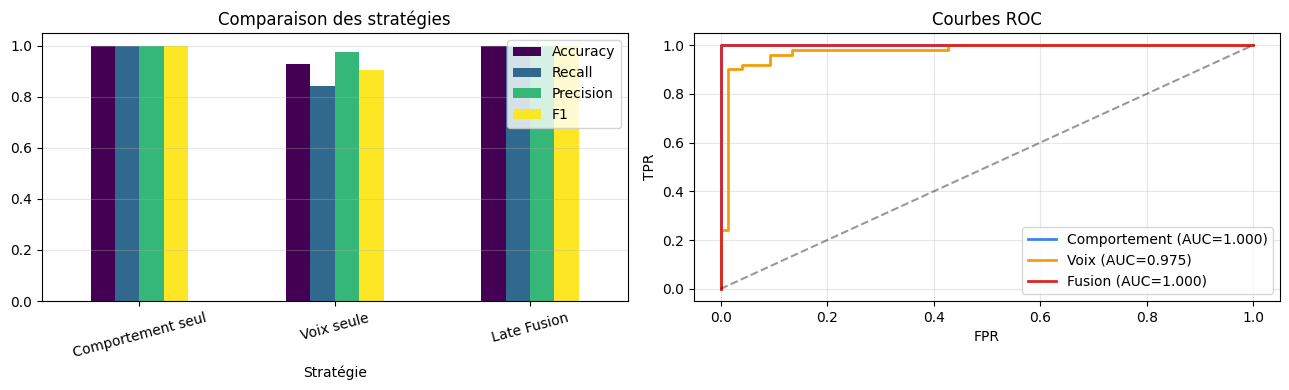

In [10]:
# ── CELLULE 5 — Late Fusion + comparaison des 3 stratégies ──────────
score_fusion = W_BEHAV * score_b + W_VOIX * score_v

results = []
for name, s, thr in [('Comportement seul', score_b,      THRESHOLD_MONO),
                     ('Voix seule',        score_v,      0.50),
                     ('Late Fusion',       score_fusion, THRESHOLD_MULTI)]:
    pred = (s >= thr).astype(int)
    fpr, tpr, _ = roc_curve(y_true, s)
    results.append({
        'Stratégie': name, 'Seuil': thr,
        'Accuracy' : accuracy_score(y_true, pred),
        'Recall'   : recall_score(y_true, pred),
        'Precision': precision_score(y_true, pred, zero_division=0),
        'F1'       : f1_score(y_true, pred, zero_division=0),
        'AUC'      : auc(fpr, tpr),
    })

df = pd.DataFrame(results)
print(df.to_string(index=False, float_format='%.3f'))

# Graphique comparatif
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
df.set_index('Stratégie')[['Accuracy','Recall','Precision','F1']].plot(
    kind='bar', ax=axes[0], colormap='viridis')
axes[0].set_title('Comparaison des stratégies'); axes[0].set_ylim(0, 1.05)
axes[0].grid(axis='y', alpha=0.3); axes[0].tick_params(axis='x', rotation=15)

for name, s, c in [('Comportement', score_b, '#3b82f6'),
                   ('Voix',         score_v, '#f59e0b'),
                   ('Fusion',       score_fusion, '#dc2626')]:
    fpr, tpr, _ = roc_curve(y_true, s)
    axes[1].plot(fpr, tpr, color=c, lw=2, label=f'{name} (AUC={auc(fpr,tpr):.3f})')
axes[1].plot([0,1],[0,1],'k--',alpha=0.4)
axes[1].set_title('Courbes ROC'); axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].legend(loc='lower right'); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.savefig(f'{OUTPUT_DIR}/comparison.png', dpi=120); plt.show()

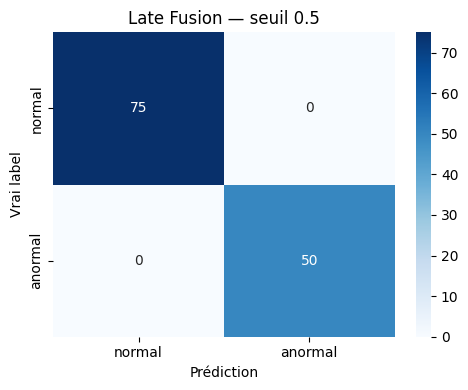

TN=75 FP=0 FN=0 TP=50
Recall anormal : 100.0%   ← métrique critique
False alarm    : 0.0%

              precision    recall  f1-score   support

      normal       1.00      1.00      1.00        75
     anormal       1.00      1.00      1.00        50

    accuracy                           1.00       125
   macro avg       1.00      1.00      1.00       125
weighted avg       1.00      1.00      1.00       125



In [11]:
# ── CELLULE 6 — Évaluation finale & matrice de confusion ────────────
final_pred = (score_fusion >= THRESHOLD_MULTI).astype(int)

cm = confusion_matrix(y_true, final_pred)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['normal','anormal'],
            yticklabels=['normal','anormal'], ax=ax)
ax.set_title(f'Late Fusion — seuil {THRESHOLD_MULTI}')
ax.set_xlabel('Prédiction'); ax.set_ylabel('Vrai label')
plt.tight_layout(); plt.savefig(f'{OUTPUT_DIR}/cm.png', dpi=120); plt.show()

print(f'TN={tn} FP={fp} FN={fn} TP={tp}')
print(f'Recall anormal : {tp/(tp+fn)*100:.1f}%   ← métrique critique')
print(f'False alarm    : {fp/(fp+tn)*100:.1f}%')
print()
print(classification_report(y_true, final_pred, target_names=['normal','anormal']))

In [12]:
# ── CELLULE 7 — Pipeline d'inférence robuste (prod) ─────────────────
def predict_dog(behav_p, voix_p=None, voice_present=True):
    """Décision finale + explication, gère le cas sans voix.
    
    Args:
        behav_p       : np.array (16,) probas softmax comportement
        voix_p        : np.array (5,)  probas softmax voix (None si silence)
        voice_present : bool, True si vocalisation détectée
    """
    s_b = float(behav_p[BEHAV_ANORMAL_IDX].sum())
    top_behav = BEHAV_CLASSES[int(behav_p.argmax())]

    if voice_present and voix_p is not None:
        s_v = float(voix_p[VOIX_ANORMAL_IDX].sum())
        top_voix = VOIX_CLASSES[int(voix_p.argmax())]
        score = W_BEHAV * s_b + W_VOIX * s_v
        threshold, mode = THRESHOLD_MULTI, 'multimodal'
    else:
        s_v, top_voix = None, None
        score = s_b
        threshold, mode = THRESHOLD_MONO, 'comportement_seul'

    # Règle de sécurité : si comportement très anormal → ANORMAL d'office
    if s_b >= 0.70:
        decision = 'ANORMAL'
    else:
        decision = 'ANORMAL' if score >= threshold else 'NORMAL'

    return {
        'decision'  : decision,
        'mode'      : mode,
        'score'     : round(score, 3),
        'confidence': round(score if decision=='ANORMAL' else 1-score, 3),
        'score_behav': round(s_b, 3),
        'score_voix' : round(s_v, 3) if s_v is not None else None,
        'top_behav'  : top_behav,
        'top_voix'   : top_voix,
        'threshold'  : threshold,
    }

# Tests
print('▶ Cas multimodal :', predict_dog(joint_b[0], joint_v[0], True))
print('▶ Cas sans voix :',  predict_dog(joint_b[0], None, False))

▶ Cas multimodal : {'decision': 'ANORMAL', 'mode': 'multimodal', 'score': 0.765, 'confidence': 0.765, 'score_behav': 0.984, 'score_voix': 0.438, 'top_behav': 'seizure', 'top_voix': 'whine', 'threshold': 0.5}
▶ Cas sans voix : {'decision': 'ANORMAL', 'mode': 'comportement_seul', 'score': 0.984, 'confidence': 0.984, 'score_behav': 0.984, 'score_voix': None, 'top_behav': 'seizure', 'top_voix': None, 'threshold': 0.55}


In [13]:
# ── CELLULE 8 — Sauvegarde config ───────────────────────────────────
config = {
    'w_behav': W_BEHAV, 'w_voix': W_VOIX,
    'threshold_multimodal': THRESHOLD_MULTI,
    'threshold_monomodal' : THRESHOLD_MONO,
    'safety_rule_behav_threshold': 0.70,
    'behav_classes': BEHAV_CLASSES,  'behav_anormal': BEHAV_ANORMAL,
    'voix_classes' : VOIX_CLASSES,   'voix_anormal' : VOIX_ANORMAL,
    'metrics_multimodal': {
        'accuracy' : float(accuracy_score(y_true, final_pred)),
        'recall'   : float(recall_score(y_true, final_pred)),
        'precision': float(precision_score(y_true, final_pred)),
        'f1'       : float(f1_score(y_true, final_pred)),
    }
}
with open(f'{OUTPUT_DIR}/late_fusion_config.json', 'w') as f:
    json.dump(config, f, indent=2, ensure_ascii=False)

print('✅ Config sauvegardée :')
for f in os.listdir(OUTPUT_DIR):
    print(f'   📦 {f}')

✅ Config sauvegardée :
   📦 late_fusion_config.json
   📦 comparison.png
   📦 cm.png


## 📌 Résumé

- **Mode multimodal** : `score = 0.6 × comportement + 0.4 × voix`, seuil 0.50
- **Mode mono-modal** (vidéo silencieuse) : `score = comportement`, seuil 0.55
- **Règle de sécurité** : score comportement ≥ 0.70 → ANORMAL (signes visuels seuls suffisants)

La fonction `predict_dog()` gère automatiquement les deux cas via le flag `voice_present`.